In [2]:
import yaml
import json
import pickle
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import httpx

import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from prolific import ProlificAPIError, ProlificClient

pd.set_option('display.max_columns', None)

config = yaml.safe_load(open("config.yaml", "r"))

client = ProlificClient(
    api_token=config["prolific_key"],
)

# API Testing

In [57]:
ID = "68f6527fd25ed8a3819ea600"

In [5]:
client.get_study(ID)

{'id': '68f6527fd25ed8a3819ea600',
 'name': 'Evaluating the political leaning of statements from debates.',
 'description': '<p>You will be looking at statements derived from comments made in political debates. The two statements (labelled &quot;Proposition&quot; and &quot;Locution&quot;) relate to the same spoken comment: &quot;Locution&quot; is a direct transcription of the comment, while &quot;Proposition&quot; is a rephrased version of the same comment to include relevant context/names.</p><p>Taking these two pieces of text together, you are required to determine <strong>whether the spoken comment has a political leaning</strong> or not.</p>',
 'total_available_places': 600,
 'reward': 47,
 'average_reward_per_hour': 1422.0,
 'external_study_url': 'https://tars.dcp.prod.aws.prolific.co/access-details/1d086311-712f-4c9d-9be7-fbc2a35a6ce2/allocate',
 'device_compatibility': ['desktop', 'mobile', 'tablet'],
 'peripheral_requirements': [],
 'researcher': {'id': '688784726462d228c69fdd6

In [17]:
responses = client.list_submissions(study=ID, page_size=1000)
print(len(responses['results']))
print(json.dumps(responses['results'][0], indent=2))

643
{
  "id": "68f6583d7b1dcc7ef7131260",
  "participant_id": "5bbf68dc527b330001e9c829",
  "started_at": "2025-10-20T15:41:53.976000Z",
  "completed_at": "2025-10-20T15:42:29.946000Z",
  "is_complete": true,
  "time_taken": 35,
  "reward": 4700,
  "status": "AWAITING REVIEW",
  "strata": {},
  "study_code": "NOCODE",
  "bonus_payments": [],
  "ip": "92.24.161.47",
  "return_requested": null,
  "has_siblings": false,
  "time_taken_under_auto_approval_threshold": true,
  "dynamic_payment_percentage": null
}


In [18]:
sub = client.get_submission(responses['results'][0]['id'])
sub

{'id': '68f6583d7b1dcc7ef7131260',
 'status': 'AWAITING REVIEW',
 'participant': '5bbf68dc527b330001e9c829',
 'datetime_created': '2025-10-20T15:41:49Z',
 'started_at': '2025-10-20T15:41:53.976000Z',
 'ip': '92.24.161.47',
 'completed_at': '2025-10-20T15:42:29.946000Z',
 'payment_sent_at': None,
 'emailed_at': None,
 'timed_out_permenant': False,
 'started_index': 363,
 'is_approved': None,
 'entered_code': 'NOCODE',
 'reviewed_at': None,
 'returned_at': None,
 'discount_amount': 0,
 'study': None,
 'time_remaining': 0,
 'study_url': 'https://tars.dcp.prod.aws.prolific.co/access-details/1d086311-712f-4c9d-9be7-fbc2a35a6ce2/allocate',
 'study_code': 'NOCODE',
 'study_id': '68f6527fd25ed8a3819ea600',
 'reserve_until': None,
 'return_requested': None,
 'bonus_payments': [],
 'parent_study_id': None,
 '_links': {'self': {'href': 'https://api.prolific.com/api/v1/submissions/68f6583d7b1dcc7ef7131260/',
   'title': 'Current'},
  'related': [{'href': 'https://api.prolific.com/api/v1/studies/68

# POLPOS_NAN

## Process results

In [2]:
results = pd.read_csv('data/polpos_nan_2010/prolific_results.csv')

results.rename(columns={c:c.lower().replace("(","").replace(")","").replace(" ","_") for c in results.columns}, inplace=True)
results.rename(columns={c:c.replace("annotator","a") for c in results.columns if "annotator" in c}, inplace=True)

results["a1_label"] = results.a1_response.map({"Yes": 1, "No": 0})
results["a2_label"] = results.a2_response.map({"Yes": 1, "No": 0})
results["a3_label"] = results.a3_response.map({"Yes": 1, "No": 0})

results['judgements'] = results.apply(lambda r: (r.a1_label, r.a2_label, r.a3_label), axis=1)
results['judgements_mean'] = results['judgements'].apply(lambda x: np.mean(x))
results['judgements_maj'] = results['judgements_mean'].apply(lambda x: 1 if x > 0.5 else 0)

# dfr: one row per data point, one column per annot
dfr = results[['meta_id', 'a1_id', 'a2_id', 'a3_id', 'a1_label', 'a2_label', 'a3_label', 'judgements', 'judgements_mean', 'judgements_maj']]

# dfl: one row per annotation
long = []
for _, row in dfr.iterrows():
    for i in [1,2,3]:
        long.append({
            'meta_id': row['meta_id'],
            'a_id': row[f'a{i}_id'],
            'label': row[f'a{i}_label'],
        })
dfl = pd.DataFrame(long)

# dfd: demographic info
demo = pd.read_csv('data/polpos_nan_2010/prolific_demographics.csv')
demo.rename(columns={c:c.lower().replace("(","").replace(")","").replace(" ","_") for c in demo.columns}, inplace=True)
dfd = demo[['participant_id', 'age', 'political_affiliation_uk', 'sex']]

# dfo: original model predictions
orig = pd.DataFrame(pickle.load(open('data/polpos_nan_2010/sample_1000_2025-10-17.pkl', 'rb'))).rename(columns={"META_id":"meta_id"})
cols = ['meta_id','n_type'] + [c for c in orig.columns if "political_position_probability_of_na" in c]
dfo = orig[cols]

# dfld: one row per annotation with demographic info
dfld = dfl.merge(dfd, left_on='a_id', right_on='participant_id', how='left').drop(columns=['a_id'])

# dfldo: one row per annotation with demographic info and original data info
dfldo = dfld.merge(dfo, on='meta_id', how='left')

# dfro: one row per data point with original data info
dfro = dfr.merge(dfo, on='meta_id', how='left')

display(dfldo.head(5))
display(dfro.head(5))

dfldo.to_csv('data/polpos_nan_2010/results_long_merged.csv', index=False, encoding='utf-8')
dfro.to_csv('data/polpos_nan_2010/results_merged.csv', index=False, encoding='utf-8')

,meta_id,label,participant_id,age,political_affiliation_uk,sex,n_type,phi_4_political_position_probability_of_na,deepseek_v3_political_position_probability_of_na,llama3_2_3b_political_position_probability_of_na,mistral_7b_political_position_probability_of_na,llama_3_3_70b_instruct_political_position_probability_of_na,qwen3_235b_a22b_political_position_probability_of_na,llama_3_1_405b_instruct_political_position_probability_of_na,claude_3_5_haiku_2024102_political_position_probability_of_na,deepseek_r1_political_position_probability_of_na,gpt_4o_mini_2024_07_18_political_position_probability_of_na,gpt_3_5_turbo_0125_political_position_probability_of_na,llama_4_maverick_political_position_probability_of_na,gemini_2_5_flash_preview_political_position_probability_of_na,claude_3_7_sonnet_20250219_political_position_probability_of_na,qwen_qwq_32b_political_position_probability_of_na,gpt_4_turbo_2024_04_09_political_position_probability_of_na,ensemble3_political_position_probability_of_na,gemini_1_5_pro_002_political_position_probability_of_na,grok_2_1212_political_position_probability_of_na,ensemble1_political_position_probability_of_na,o3_mini_2025_01_31_political_position_probability_of_na,gpt_4o_2024_08_06_political_position_probability_of_na,gpt_4_5_preview_2025_02_27_political_position_probability_of_na,ensemble2_political_position_probability_of_na,llama3_1_8b_political_position_probability_of_na
0,fqkBcyhLDW2qMv9vyYFsbF,1,5953668fb2e8430001ea478f,40,Centre,Female,high,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.8,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.983333,1.0,1.0,0.709091,0.8,1.0,1.0,0.92,0.0
1,fqkBcyhLDW2qMv9vyYFsbF,0,6142013d4dd8ae5ca2b4329b,51,Centre,Male,high,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.8,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.983333,1.0,1.0,0.709091,0.8,1.0,1.0,0.92,0.0
2,fqkBcyhLDW2qMv9vyYFsbF,0,676ab5c54516be2437eb0642,28,Centre,Male,high,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.8,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.983333,1.0,1.0,0.709091,0.8,1.0,1.0,0.92,0.0
3,jK9Vm4bNvafa6KXsVztUrA,1,592a8ee1dd1a250001b4ee72,74,Right,Female,low,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.033333,0.0,0.0,0.018182,0.0,0.0,0.0,0.08,0.0
4,jK9Vm4bNvafa6KXsVztUrA,1,6716152e33a2af901d7e9196,44,Left,Male,low,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.033333,0.0,0.0,0.018182,0.0,0.0,0.0,0.08,0.0


,meta_id,a1_id,a2_id,a3_id,a1_label,a2_label,a3_label,judgements,judgements_mean,judgements_maj,n_type,phi_4_political_position_probability_of_na,deepseek_v3_political_position_probability_of_na,llama3_2_3b_political_position_probability_of_na,mistral_7b_political_position_probability_of_na,llama_3_3_70b_instruct_political_position_probability_of_na,qwen3_235b_a22b_political_position_probability_of_na,llama_3_1_405b_instruct_political_position_probability_of_na,claude_3_5_haiku_2024102_political_position_probability_of_na,deepseek_r1_political_position_probability_of_na,gpt_4o_mini_2024_07_18_political_position_probability_of_na,gpt_3_5_turbo_0125_political_position_probability_of_na,llama_4_maverick_political_position_probability_of_na,gemini_2_5_flash_preview_political_position_probability_of_na,claude_3_7_sonnet_20250219_political_position_probability_of_na,qwen_qwq_32b_political_position_probability_of_na,gpt_4_turbo_2024_04_09_political_position_probability_of_na,ensemble3_political_position_probability_of_na,gemini_1_5_pro_002_political_position_probability_of_na,grok_2_1212_political_position_probability_of_na,ensemble1_political_position_probability_of_na,o3_mini_2025_01_31_political_position_probability_of_na,gpt_4o_2024_08_06_political_position_probability_of_na,gpt_4_5_preview_2025_02_27_political_position_probability_of_na,ensemble2_political_position_probability_of_na,llama3_1_8b_political_position_probability_of_na
0,fqkBcyhLDW2qMv9vyYFsbF,5953668fb2e8430001ea478f,6142013d4dd8ae5ca2b4329b,676ab5c54516be2437eb0642,1,0,0,"(1, 0, 0)",0.333333,0,high,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.8,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.983333,1.0,1.0,0.709091,0.8,1.0,1.0,0.92,0.0
1,jK9Vm4bNvafa6KXsVztUrA,592a8ee1dd1a250001b4ee72,6716152e33a2af901d7e9196,5d6d68dd09274100195c5511,1,1,1,"(1, 1, 1)",1.000000,1,low,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.033333,0.0,0.0,0.018182,0.0,0.0,0.0,0.08,0.0
2,nDAXgYBK3ckoakrx3MaBMY,58cd0bc2a47dbb000171dc8b,5c5b66cb3312f1000112f694,60d075b6af3d46debaf3cfd8,0,0,0,"(0, 0, 0)",0.000000,0,low,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.033333,0.0,0.0,0.018182,0.0,0.0,0.0,0.08,0.0
3,CT4XMwh7Jn5SNLCCoFhX9T,66ae405b697e97b6ddc29d1f,60cf0d251a90eb823bc9b740,6125646031b73d8171421e7c,0,0,0,"(0, 0, 0)",0.000000,0,high,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.8,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.983333,1.0,1.0,0.718182,1.0,1.0,1.0,0.96,0.0
4,KFb7qTSs4bZkUYrrKzxAoR,648978eef0a4e73b67c9c153,5dee48a67309b94df13ddbce,60bf706fc3b12a3c4f11a487,0,0,0,"(0, 0, 0)",0.000000,0,high,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.8,0.8,1.0,1.0,1.0,1.0,0.6,1.0,0.983333,1.0,1.0,0.681818,0.8,1.0,1.0,0.84,0.0


In [ ]:
# Investigate uniform labelling by annotators

pids = dfldo['participant_id'].unique()

for pid in pids:
    subdf = dfldo[dfldo['participant_id'] == pid]
    if sum(subdf['label'])==0 or sum(subdf['label'])==len(subdf):
        indiv_human_comparison = []
        for _, row in subdf.iterrows():
            otherpreds = dfldo.loc[(dfldo.meta_id==row.meta_id)&(dfldo.participant_id!=pid), 'label'].tolist()
            indiv_human_comparison.append(otherpreds)
        
        human_predicted = sum([np.mean(preds) for preds in indiv_human_comparison])
        human_diff = abs(human_predicted - sum(subdf['label']))/len(subdf)

        model_predicted = sum([1-v for v in subdf['ensemble3_political_position_probability_of_na']])
        model_diff = abs(model_predicted - sum(subdf['label']))/len(subdf)

        if model_diff > .2 and human_diff > .2:
            print(f"Participant {pid} uniform {sum(subdf['label'])/len(subdf)}")
            print(f"| Model predicted: {model_predicted/len(subdf):.3f}, diff: {model_diff:.0%}")
            print(f"| Other humans predicted: {human_predicted/len(subdf):.3f}, diff: {human_diff:.0%}")

Participant 63f93b47bb0c1a1aca131480 uniform 0.0
| Model predicted: 0.987, diff: 99%
| Other humans predicted: 0.800, diff: 80%
Participant 5dacdf401e90f600132de0e6 uniform 0.0
| Model predicted: 0.990, diff: 99%
| Other humans predicted: 0.400, diff: 40%
Participant 60f059aff7f931e2d83bacb5 uniform 1.0
| Model predicted: 0.490, diff: 51%
| Other humans predicted: 0.600, diff: 40%
Participant 57c426fa9fe51d00012391f1 uniform 0.0
| Model predicted: 0.523, diff: 52%
| Other humans predicted: 0.500, diff: 50%
Participant 5e32db8f239ceb2a8e57d928 uniform 0.0
| Model predicted: 0.997, diff: 100%
| Other humans predicted: 0.600, diff: 60%
Participant 5d7fea714477a000012cc297 uniform 0.0
| Model predicted: 0.523, diff: 52%
| Other humans predicted: 0.300, diff: 30%
Participant 5c65322cb0839200019ab27a uniform 0.0
| Model predicted: 0.520, diff: 52%
| Other humans predicted: 0.300, diff: 30%
Participant 5b10527374db8f00013fdc57 uniform 0.0
| Model predicted: 0.513, diff: 51%
| Other humans pre

In [ ]:
participants = dfldo['participant_id'].unique()
nonparticipants = demo[~demo['participant_id'].isin(participants)]['participant_id'].unique()

print(len(participants), len(nonparticipants))

600 43


In [104]:
with open('approve.txt', 'w') as f:
    for pid in participants:
        f.write(f"{pid}\n")

## Analysis

In [37]:
df = pd.read_csv('data/polpos_nan_2010/results_merged.csv')

df.n_type = df.n_type.map({'low': '0.low', 'mid': '1.mid', 'high': '2.high'})
models = list(set([c for c in df.columns if "political_position_probability_of_na" in c]))
clean_models = ['_'.join(c.replace("_political_position_probability_of_na","").split('_')[0:3]) for c in models]
modelmap = dict(zip(models, clean_models))
print(clean_models)

df.rename(columns=modelmap, inplace=True)

models = clean_models
display(df.head(5))

['gemini_2_5', 'ensemble3', 'gpt_4o_mini', 'ensemble2', 'llama_3_1', 'llama3_2_3b', 'qwen3_235b_a22b', 'gpt_4_turbo', 'gpt_3_5', 'deepseek_v3', 'phi_4', 'o3_mini_2025', 'llama3_1_8b', 'mistral_7b', 'gpt_4o_2024', 'gpt_4_5', 'llama_3_3', 'grok_2_1212', 'gemini_1_5', 'deepseek_r1', 'qwen_qwq_32b', 'claude_3_7', 'llama_4_maverick', 'ensemble1', 'claude_3_5']


,meta_id,a1_id,a2_id,a3_id,a1_label,a2_label,a3_label,judgements,judgements_mean,judgements_maj,n_type,phi_4,deepseek_v3,llama3_2_3b,mistral_7b,llama_3_3,qwen3_235b_a22b,llama_3_1,claude_3_5,deepseek_r1,gpt_4o_mini,gpt_3_5,llama_4_maverick,gemini_2_5,claude_3_7,qwen_qwq_32b,gpt_4_turbo,ensemble3,gemini_1_5,grok_2_1212,ensemble1,o3_mini_2025,gpt_4o_2024,gpt_4_5,ensemble2,llama3_1_8b
0,fqkBcyhLDW2qMv9vyYFsbF,5953668fb2e8430001ea478f,6142013d4dd8ae5ca2b4329b,676ab5c54516be2437eb0642,1,0,0,"(1, 0, 0)",0.333333,0,2.high,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.8,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.983333,1.0,1.0,0.709091,0.8,1.0,1.0,0.92,0.0
1,jK9Vm4bNvafa6KXsVztUrA,592a8ee1dd1a250001b4ee72,6716152e33a2af901d7e9196,5d6d68dd09274100195c5511,1,1,1,"(1, 1, 1)",1.000000,1,0.low,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.033333,0.0,0.0,0.018182,0.0,0.0,0.0,0.08,0.0
2,nDAXgYBK3ckoakrx3MaBMY,58cd0bc2a47dbb000171dc8b,5c5b66cb3312f1000112f694,60d075b6af3d46debaf3cfd8,0,0,0,"(0, 0, 0)",0.000000,0,0.low,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.033333,0.0,0.0,0.018182,0.0,0.0,0.0,0.08,0.0
3,CT4XMwh7Jn5SNLCCoFhX9T,66ae405b697e97b6ddc29d1f,60cf0d251a90eb823bc9b740,6125646031b73d8171421e7c,0,0,0,"(0, 0, 0)",0.000000,0,2.high,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.8,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.983333,1.0,1.0,0.718182,1.0,1.0,1.0,0.96,0.0
4,KFb7qTSs4bZkUYrrKzxAoR,648978eef0a4e73b67c9c153,5dee48a67309b94df13ddbce,60bf706fc3b12a3c4f11a487,0,0,0,"(0, 0, 0)",0.000000,0,2.high,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.8,0.8,1.0,1.0,1.0,1.0,0.6,1.0,0.983333,1.0,1.0,0.681818,0.8,1.0,1.0,0.84,0.0


In [38]:
# boolean labels
df_bool = df.copy().drop(columns=['a1_id', 'a2_id', 'a3_id', 'a1_label', 'a2_label', 'a3_label', 'judgements', 'judgements_mean']).rename(
    columns={
        "judgements_maj":"human"
    }
)
for model in models:
    df_bool[model] = df_bool[model].apply(lambda x: 1 if x < 0.5 else 0)

# probability labels
df_prob = df.copy().drop(columns=['a1_id', 'a2_id', 'a3_id', 'a1_label', 'a2_label', 'a3_label', 'judgements', 'judgements_maj']).rename(
    columns={
        "judgements_mean":"human"
    }
)
for model in models:
    df_prob[model] = 1 - df_prob[model]  # convert to probability of NOT being NA

# binned version of df_prob, 4 bins i.e. [0,.25,.5,.75,1], label as 1,2,3,4,
bins = [0, .25, .5, .75, 1.0]
df_bin = df_prob.copy()

df_bin['human'] = pd.cut(df_bin['human'], bins=bins, labels=[1,2,3,4], include_lowest=True)
for model in models:
    df_bin[model] = pd.cut(df_bin[model], bins=bins, labels=[1,2,3,4], include_lowest=True)


display(df_bool.head(5))
display(df_prob.head(5))
display(df_bin.head(5))

,meta_id,human,n_type,phi_4,deepseek_v3,llama3_2_3b,mistral_7b,llama_3_3,qwen3_235b_a22b,llama_3_1,claude_3_5,deepseek_r1,gpt_4o_mini,gpt_3_5,llama_4_maverick,gemini_2_5,claude_3_7,qwen_qwq_32b,gpt_4_turbo,ensemble3,gemini_1_5,grok_2_1212,ensemble1,o3_mini_2025,gpt_4o_2024,gpt_4_5,ensemble2,llama3_1_8b
0,fqkBcyhLDW2qMv9vyYFsbF,0,2.high,0,0,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,jK9Vm4bNvafa6KXsVztUrA,1,0.low,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2,nDAXgYBK3ckoakrx3MaBMY,0,0.low,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
3,CT4XMwh7Jn5SNLCCoFhX9T,0,2.high,0,0,1,1,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,KFb7qTSs4bZkUYrrKzxAoR,0,2.high,0,0,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


,meta_id,human,n_type,phi_4,deepseek_v3,llama3_2_3b,mistral_7b,llama_3_3,qwen3_235b_a22b,llama_3_1,claude_3_5,deepseek_r1,gpt_4o_mini,gpt_3_5,llama_4_maverick,gemini_2_5,claude_3_7,qwen_qwq_32b,gpt_4_turbo,ensemble3,gemini_1_5,grok_2_1212,ensemble1,o3_mini_2025,gpt_4o_2024,gpt_4_5,ensemble2,llama3_1_8b
0,fqkBcyhLDW2qMv9vyYFsbF,0.333333,2.high,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.016667,0.0,0.0,0.290909,0.2,0.0,0.0,0.08,1.0
1,jK9Vm4bNvafa6KXsVztUrA,1.000000,0.low,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.6,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.966667,1.0,1.0,0.981818,1.0,1.0,1.0,0.92,1.0
2,nDAXgYBK3ckoakrx3MaBMY,0.000000,0.low,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.6,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.966667,1.0,1.0,0.981818,1.0,1.0,1.0,0.92,1.0
3,CT4XMwh7Jn5SNLCCoFhX9T,0.000000,2.high,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.016667,0.0,0.0,0.281818,0.0,0.0,0.0,0.04,1.0
4,KFb7qTSs4bZkUYrrKzxAoR,0.000000,2.high,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.2,0.2,0.0,0.0,0.0,0.0,0.4,0.0,0.016667,0.0,0.0,0.318182,0.2,0.0,0.0,0.16,1.0


,meta_id,human,n_type,phi_4,deepseek_v3,llama3_2_3b,mistral_7b,llama_3_3,qwen3_235b_a22b,llama_3_1,claude_3_5,deepseek_r1,gpt_4o_mini,gpt_3_5,llama_4_maverick,gemini_2_5,claude_3_7,qwen_qwq_32b,gpt_4_turbo,ensemble3,gemini_1_5,grok_2_1212,ensemble1,o3_mini_2025,gpt_4o_2024,gpt_4_5,ensemble2,llama3_1_8b
0,fqkBcyhLDW2qMv9vyYFsbF,2,2.high,1,1,4,4,4,1,4,4,1,1,1,1,1,1,1,1,1,1,1,2,1,1,1,1,4
1,jK9Vm4bNvafa6KXsVztUrA,4,0.low,4,4,4,4,4,4,4,4,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
2,nDAXgYBK3ckoakrx3MaBMY,1,0.low,4,4,4,4,4,4,4,4,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
3,CT4XMwh7Jn5SNLCCoFhX9T,1,2.high,1,1,4,4,1,1,4,4,1,4,1,1,1,1,1,1,1,1,1,2,1,1,1,1,4
4,KFb7qTSs4bZkUYrrKzxAoR,1,2.high,1,1,4,4,4,1,4,4,1,1,1,1,1,1,2,1,1,1,1,2,1,1,1,1,4


In [39]:
print("Positive labels:", df_bool['human'].sum())
print("Negative labels:", len(df_bool)-df_bool['human'].sum())

print("Buckets")
for bucket in ['0.low', '1.mid', '2.high']:
    buckets = df_bool[df_bool.n_type==bucket]['meta_id'].tolist()
    print(f"{bucket}: {len(buckets)}")

print() 

print("Buckets for positive labels:")
display(df_bool[df_bool.human==1].n_type.value_counts(dropna=False))

print("Buckets for negative labels:")
display(df_bool[df_bool.human==0].n_type.value_counts(dropna=False))

print("Low Bucket:", df_bool[(df_bool.n_type=='0.low')&(df_bool.human==1)].shape[0], "positive labels,", df_bool[(df_bool.n_type=='0.low')&(df_bool.human==0)].shape[0], "negative labels")
print("Mid Bucket:", df_bool[(df_bool.n_type=='1.mid')&(df_bool.human==1)].shape[0], "positive labels,", df_bool[(df_bool.n_type=='1.mid')&(df_bool.human==0)].shape[0], "negative labels")
print("High Bucket:", df_bool[(df_bool.n_type=='2.high')&(df_bool.human==1)].shape[0], "positive labels,", df_bool[(df_bool.n_type=='2.high')&(df_bool.human==0)].shape[0], "negative labels")

Positive labels: 422
Negative labels: 578
Buckets
0.low: 400
1.mid: 200
2.high: 400

Buckets for positive labels:


n_type
0.low     252
1.mid      89
2.high     81
Name: count, dtype: int64

Buckets for negative labels:


n_type
2.high    319
0.low     148
1.mid     111
Name: count, dtype: int64

Low Bucket: 252 positive labels, 148 negative labels
Mid Bucket: 89 positive labels, 111 negative labels
High Bucket: 81 positive labels, 319 negative labels


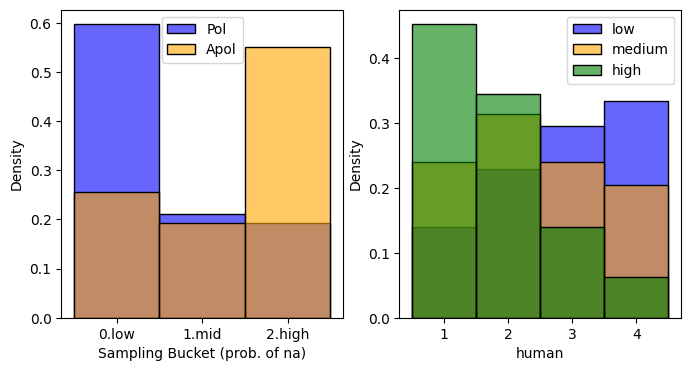

In [40]:
fig,axs = plt.subplots(1,2, figsize=(8,4))

A = .6

# 1. plot two histograms on same axes of model predictions for human=1 and human=0 by n_type
human1 = df_bool[df_bool.human==1].sort_values(by='n_type')
human0 = df_bool[df_bool.human==0].sort_values(by='n_type')
sns.histplot(human1['n_type'], color='blue', label='Pol', kde=False, stat='density', discrete=True, ax=axs[0], alpha=A)
sns.histplot(human0['n_type'], color='orange', label='Apol', kde=False, stat='density', discrete=True, ax=axs[0], alpha=A)
axs[0].set_xlabel("Sampling Bucket (prob. of na)")
axs[0].legend()

# 2. plot 3 histograms on same axes of human labels for low, med, high
low = df_bin[df_bin.n_type=='0.low']
med = df_bin[df_bin.n_type=='1.mid']
high = df_bin[df_bin.n_type=='2.high']
sns.histplot(low['human'], color='blue', label='low', kde=False, stat='density', discrete=True, ax=axs[1], alpha=A)
sns.histplot(med['human'], color='orange', label='medium', kde=False, stat='density', discrete=True, ax=axs[1], alpha=A)
sns.histplot(high['human'], color='green', label='high', kde=False, stat='density', discrete=True, ax=axs[1], alpha=A)

axs[1].legend()
plt.show()

In [77]:
buckets = {
    "all": ("0.low", "1.mid", "2.high"),
    "mid": ("1.mid",),
    "abs": ("0.low","2.high"),
}

metrics = {m:dict() for m in models}

for model, (bucket, bucket_cols) in itertools.product(models, buckets.items()):
    subdf = df_bool[df_bool.n_type.isin(bucket_cols)]
    y_true = subdf['human'].tolist()
    y_pred = subdf[model].tolist()  
    
    metrics[model][bucket] = {
        'f1': f1_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
    }

metrics

{'gemini_2_5': {'all': {'f1': 0.6611740473738414,
   'macro_f1': 0.6707230781086895,
   'precision': 0.5846994535519126,
   'recall': 0.7606635071090048,
   'balanced_acc': 0.6830999196444678},
  'mid': {'f1': 0.5798319327731093,
   'macro_f1': 0.4812739910779127,
   'precision': 0.46308724832214765,
   'recall': 0.7752808988764045,
   'balanced_acc': 0.5272800890778419},
  'abs': {'f1': 0.6875852660300137,
   'macro_f1': 0.7117280424729077,
   'precision': 0.63,
   'recall': 0.7567567567567568,
   'balanced_acc': 0.7199201342670294}},
 'ensemble3': {'all': {'f1': 0.6492942453854506,
   'macro_f1': 0.6749714971134853,
   'precision': 0.5991983967935872,
   'recall': 0.7085308056872038,
   'balanced_acc': 0.6812550222207645},
  'mid': {'f1': 0.5,
   'macro_f1': 0.5283018867924528,
   'precision': 0.47474747474747475,
   'recall': 0.5280898876404494,
   'balanced_acc': 0.5298107095859905},
  'abs': {'f1': 0.6875852660300137,
   'macro_f1': 0.7117280424729077,
   'precision': 0.63,
   're

In [78]:
def get_topn_models(n:int, bucket:str='all'):
    return sorted(models, key=lambda m: metrics[m]['all']['macro_f1'], reverse=True)[:5]

metrics_to_plot = ['macro_f1', 'precision', 'recall', 'balanced_acc']
num_models = len(models)
colors = plt.cm.tab20(np.linspace(0, 1, num_models))
linestyles = ['-', '--', '-.', ':']
markerstyles = ['o', 's', '^', 'D', 'v', 'x', '*', 'P', 'H']


top3 = get_topn_models(3)
top5 = get_topn_models(5, 'abs')
top5

['gpt_4o_2024', 'deepseek_v3', 'ensemble3', 'gpt_4_5', 'grok_2_1212']

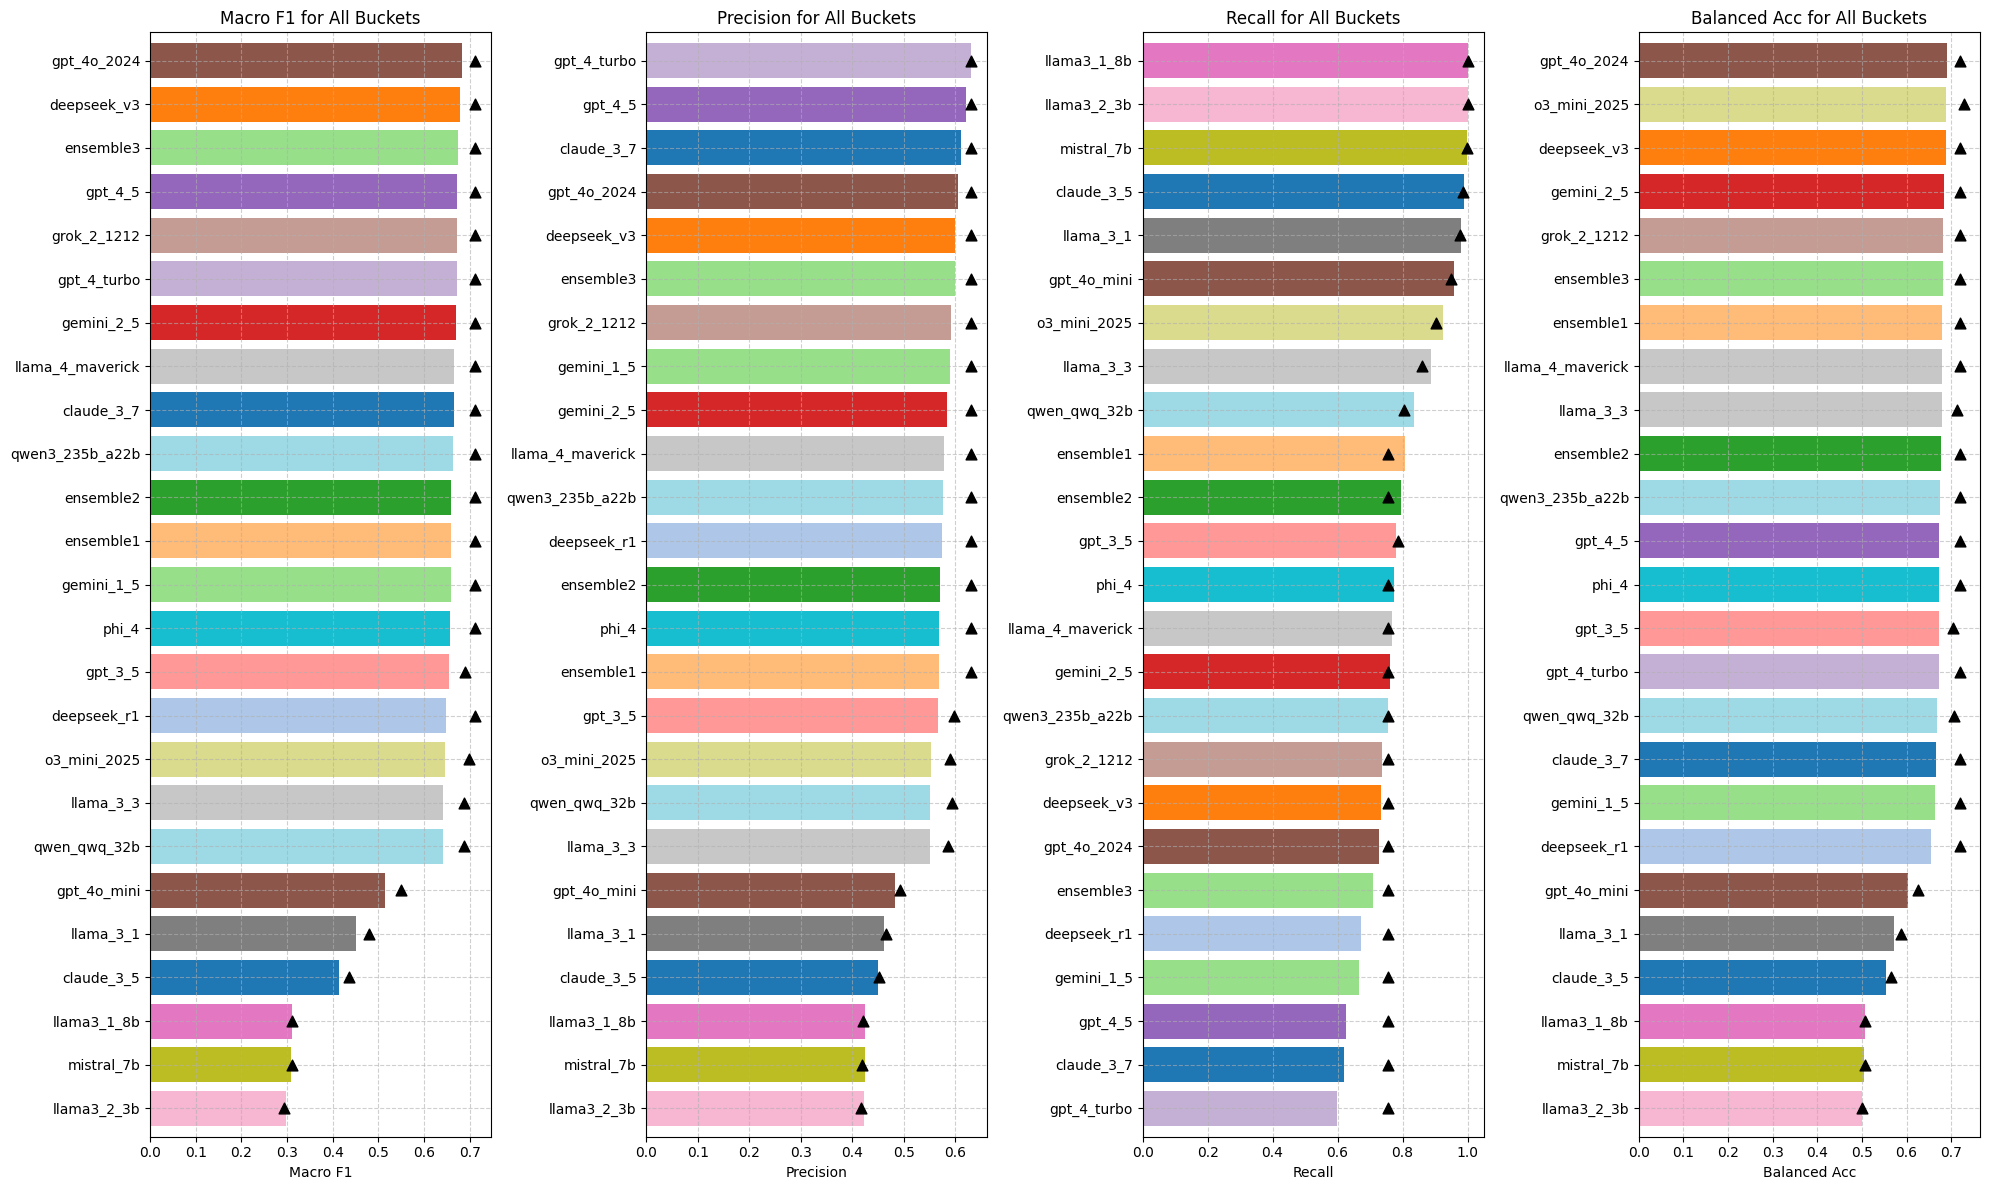

In [79]:
# plot hbar of macro f1, prec, recall, balanced acc for all models, i.e. 4 columns of hbars
fig, axs = plt.subplots(1, 4, figsize=(20, 12), sharey=False)

model_colors = {model: colors[i] for i, model in enumerate(sorted(models))}

for i, metric in enumerate(metrics_to_plot):
    # Sort models by "all" bucket
    sorted_models_by_metric = sorted(models, key=lambda m: metrics[m]['all'][metric])
    
    model_names = [model for model in sorted_models_by_metric]
    y_pos = np.arange(len(model_names))
    
    metric_values_all = [metrics[model]['all'][metric] for model in sorted_models_by_metric]
    metric_values_abs = [metrics[model]['abs'][metric] for model in sorted_models_by_metric]
    
    bar_colors = [model_colors[model] for model in sorted_models_by_metric]
    
    # Plot bars for the "all" bucket
    axs[i].barh(y_pos, metric_values_all, color=bar_colors, align='center')
    
    # Plot points for the "abs" bucket
    axs[i].scatter(metric_values_abs, y_pos, color='black', marker='^', s=60, zorder=5)
    
    axs[i].set_yticks(y_pos)
    axs[i].set_yticklabels(model_names)
    axs[i].set_xlabel(metric.replace('_', ' ').title())
    axs[i].set_title(f"{metric.replace('_', ' ').title()} for All Buckets")
    axs[i].grid(True, linestyle='--', alpha=0.6)
    
    axs[i].margins(y=0.01)

plt.tight_layout(rect=[0, 0, 1, 1]) # Adjust layout to make space for legend
plt.show()

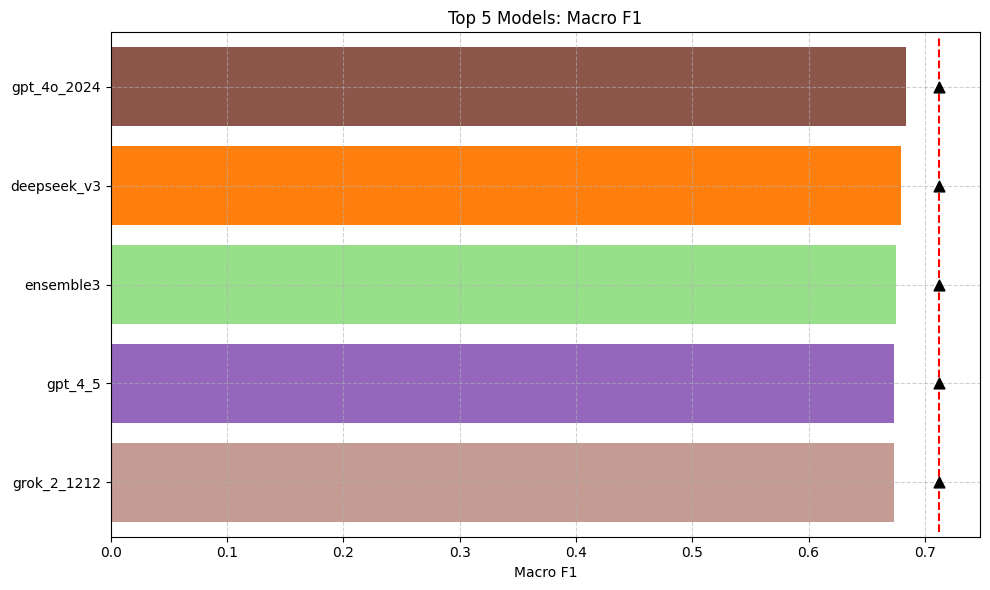

In [90]:
fig, ax = plt.subplots(figsize=(10, 6))

metric_to_plot = 'macro_f1'
sorted_top_models = get_topn_models(10, 'all')[::-1]
model_names = sorted_top_models
y_pos = np.arange(len(model_names))

metric_values_all = [metrics[model]['all'][metric_to_plot] for model in model_names]
metric_values_abs = [metrics[model]['abs'][metric_to_plot] for model in model_names]
bar_colors = [model_colors[model] for model in model_names]
ax.barh(y_pos, metric_values_all, color=bar_colors, align='center')
ax.scatter(metric_values_abs, y_pos, color='black', marker='^', s=60, zorder=5)

ax.set_yticks(y_pos)
ax.set_yticklabels(model_names)
# ax.set_xlim(0.65,0.72)
ax.set_xlabel(metric_to_plot.replace('_', ' ').title())
ax.set_title(f"Top 5 Models: {metric_to_plot.replace('_', ' ').title()}")
ax.grid(True, linestyle='--', alpha=0.6)
ax.margins(y=0.01)

ax.vlines([.7118], -0.5, 4.5, color='red', linestyles='dashed')

plt.tight_layout()
plt.show()

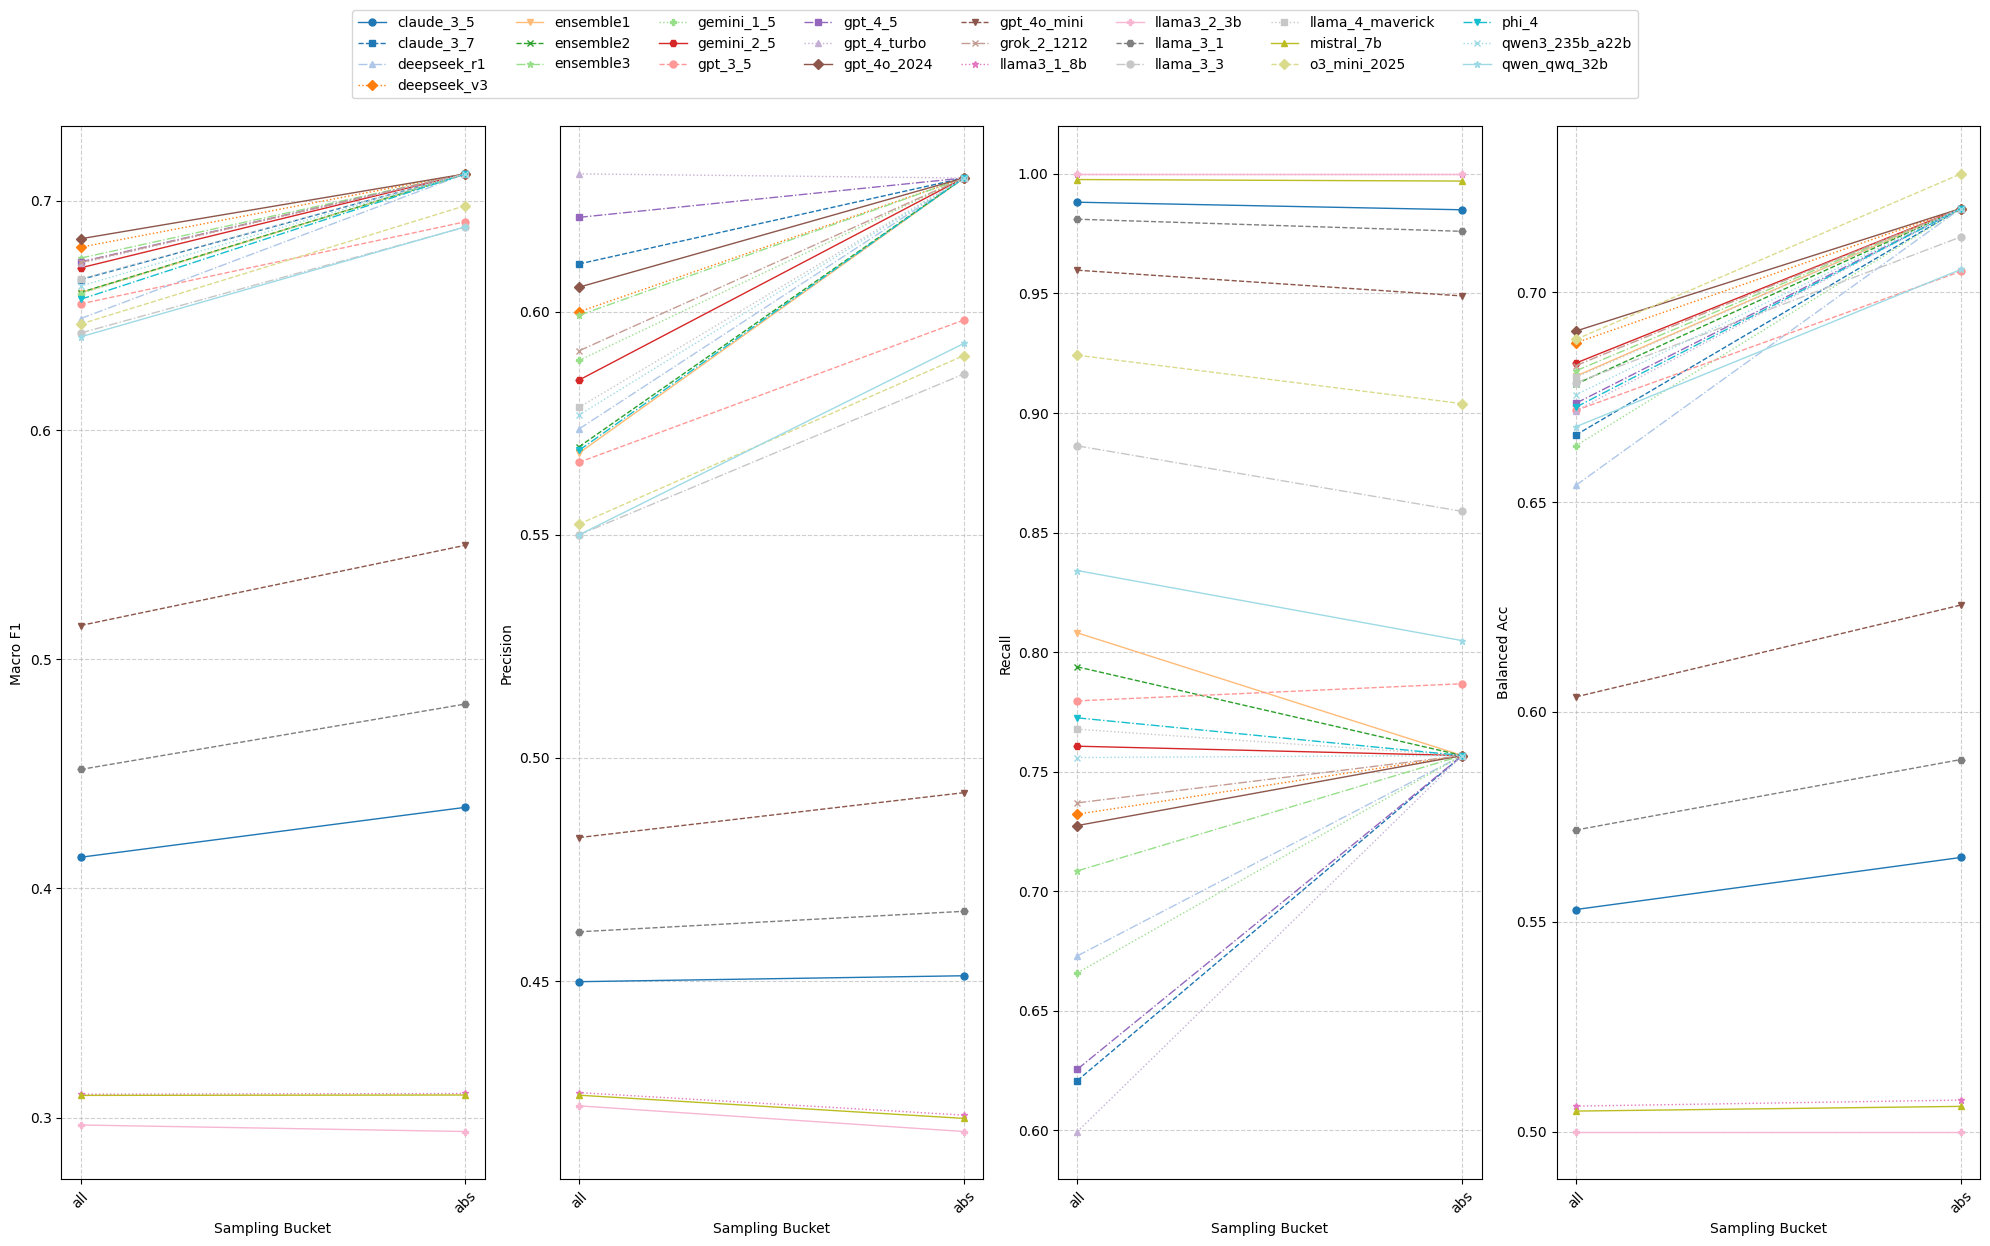

In [86]:
# plot scatter plot, f1 on y axis, bucket on x axis, one horizontal line per model
fig, axs = plt.subplots(1, 4, figsize=(20, 12), sharey=False)


# Create a style mapping for each model
model_styles = {}
sorted_models = sorted(models)
for i, model in enumerate(sorted_models):
    model_styles[model] = {
        'color': colors[i],
        'linestyle': linestyles[i % len(linestyles)],
        'marker': markerstyles[i % len(markerstyles)]
    }

for i, metric in enumerate(metrics_to_plot):
    for model in sorted_models:
        x = [b for b in list(buckets.keys()) if b!= 'mid']
        y = [metrics[model][bucket][metric] for bucket in x if bucket!= 'mid']
        style = model_styles[model]
        axs[i].plot(x, y, markersize=5, linewidth=1, label=model, **style)

    axs[i].set_xlabel("Sampling Bucket")
    axs[i].set_ylabel(metric.replace('_', ' ').title())
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].tick_params(axis='x', rotation=45)

# Create a single legend for the figure
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.09), ncol=8)

plt.tight_layout(rect=[0, 0.05, 1, 1]) # Adjust layout to make space for legend
plt.show()

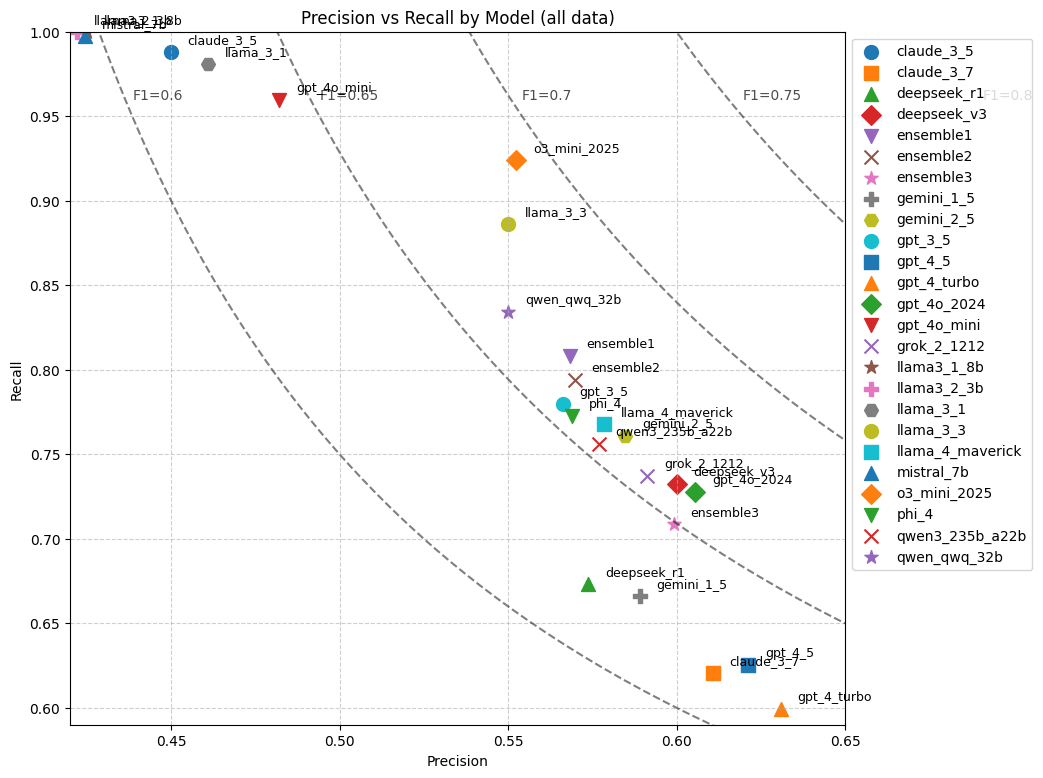

In [82]:
# plot scatter plot of precicision against recall for only the 'all' bucket
fig, ax = plt.subplots(figsize=(10,9))

# Add F1 score curves
f1_scores = [round(x,3) for x in np.linspace(0.6, 0.8, 5, True)]
for f1 in f1_scores:
    # Recall values must be > f1/2 for precision to be positive
    recall_vals = np.linspace(f1/2 + 0.01, 1, 100) 
    precision_vals = (f1 * recall_vals) / (2 * recall_vals - f1)
    # Filter out precision values > 1, which can happen with floating point inaccuracies
    valid_points = precision_vals <= 1
    ax.plot(precision_vals[valid_points], recall_vals[valid_points], 'k--', alpha=0.5)
    # Add annotation
    p_at_r95 = (f1 * 0.95) / (2 * 0.95 - f1)
    if p_at_r95 < 1:
        ax.text(p_at_r95, 0.96, f'F1={f1}', fontsize=10, color='black', alpha=0.7)


for i, model in enumerate(sorted(models)):
    precision = metrics[model]['all']['precision']
    recall = metrics[model]['all']['recall']
    ax.scatter(precision, recall, s=100, label=model, marker=markerstyles[i % len(markerstyles)])
    ax.text(precision+0.005, recall+0.005, model, fontsize=9,) 

ax.set_xlabel("Precision")
ax.set_ylabel("Recall")
ax.set_title("Precision vs Recall by Model (all data)")
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlim(0.42, 0.65)
ax.set_ylim(0.59, 1)
# ax.set_xlim(0,1)
# ax.set_ylim(0,1)
ax.legend(ncol=1, bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

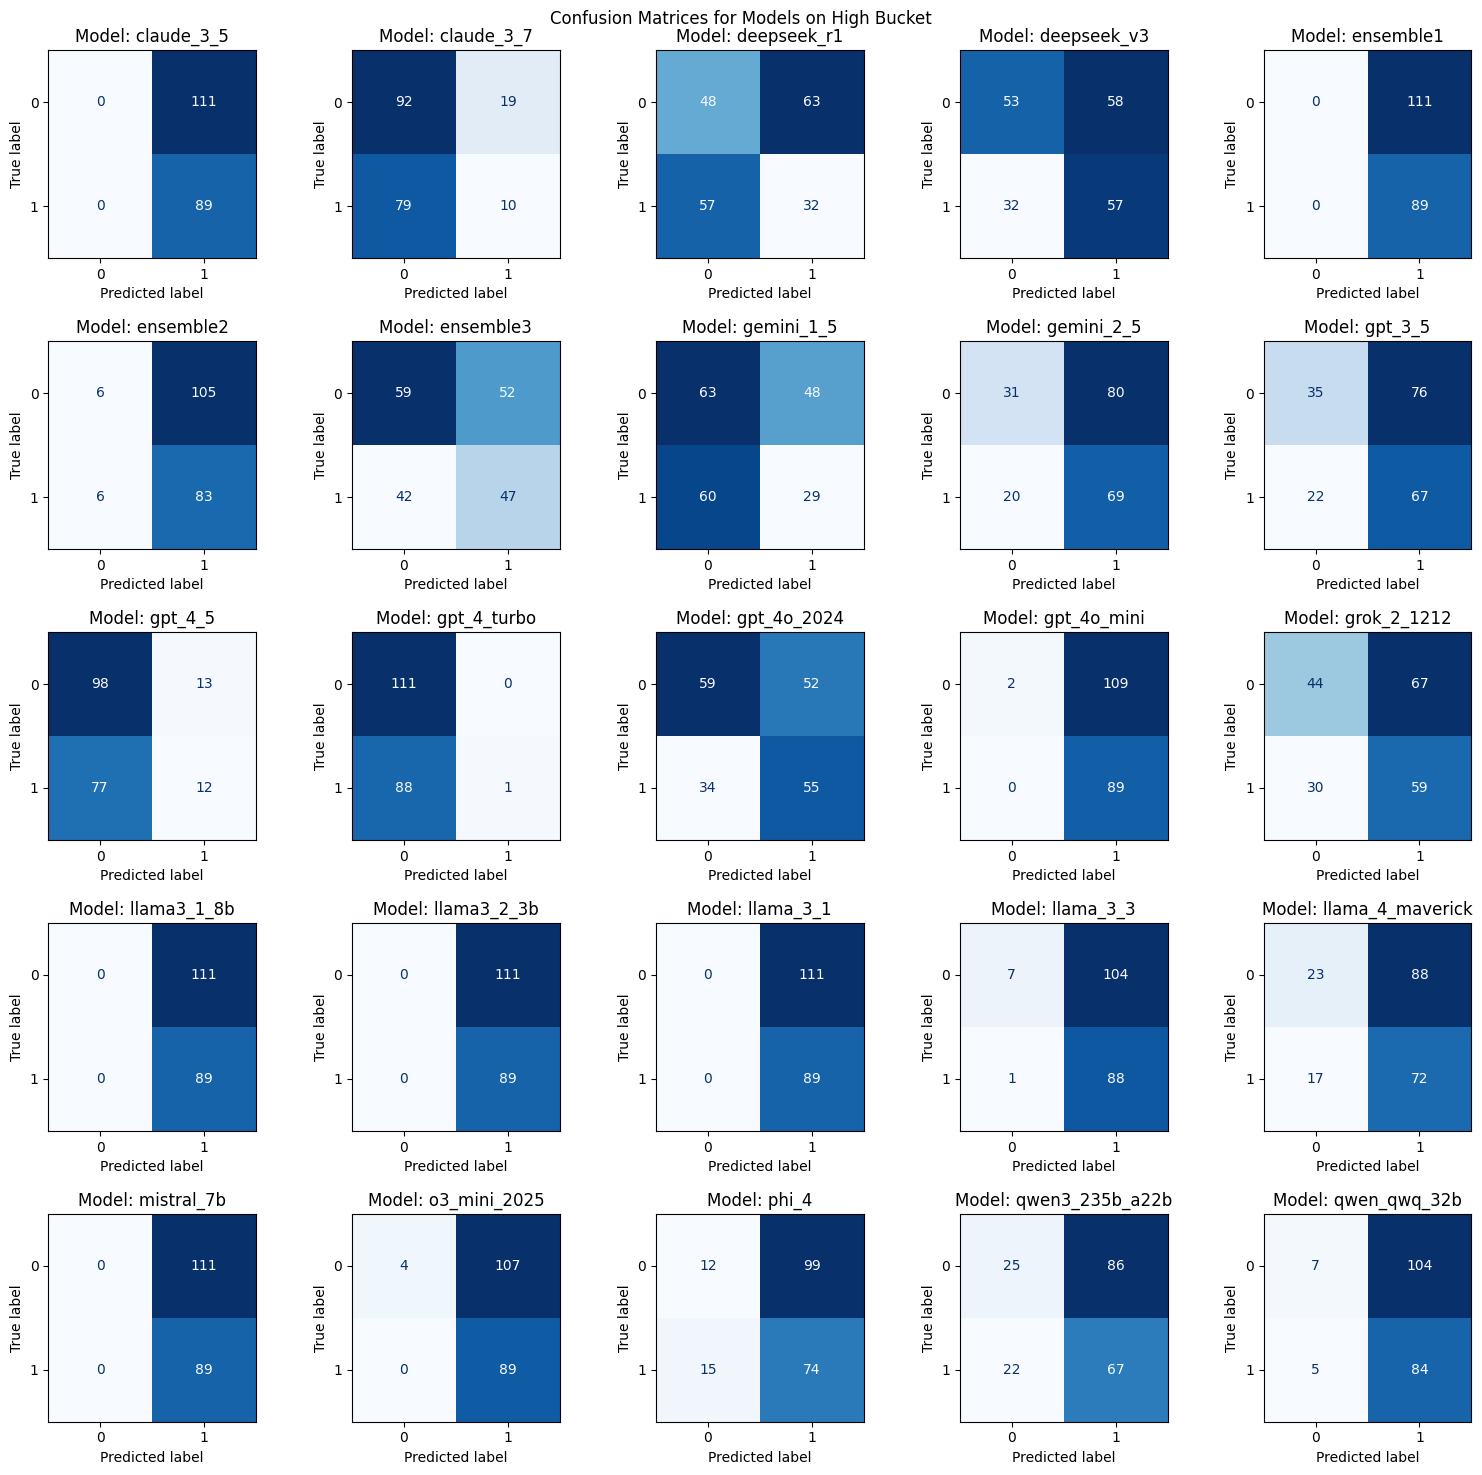

In [87]:
# plot confusion matrices for all models (5 rows, 5 columns) on "high' bucket

fig, axs = plt.subplots(5, 5, figsize=(15, 15))

for i, model in enumerate(sorted(models)):
    subdf = df_bool[df_bool.n_type.isin(buckets['mid'])]
    y_true = subdf['human'].tolist()
    y_pred = subdf[model].tolist()
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    row = i // 5
    col = i % 5
    disp.plot(cmap=plt.cm.Blues, ax=axs[row, col], colorbar=False)
    axs[row, col].set_title(f"Model: {model}")

plt.suptitle("Confusion Matrices for Models on High Bucket", fontsize=12)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.4)
plt.show()

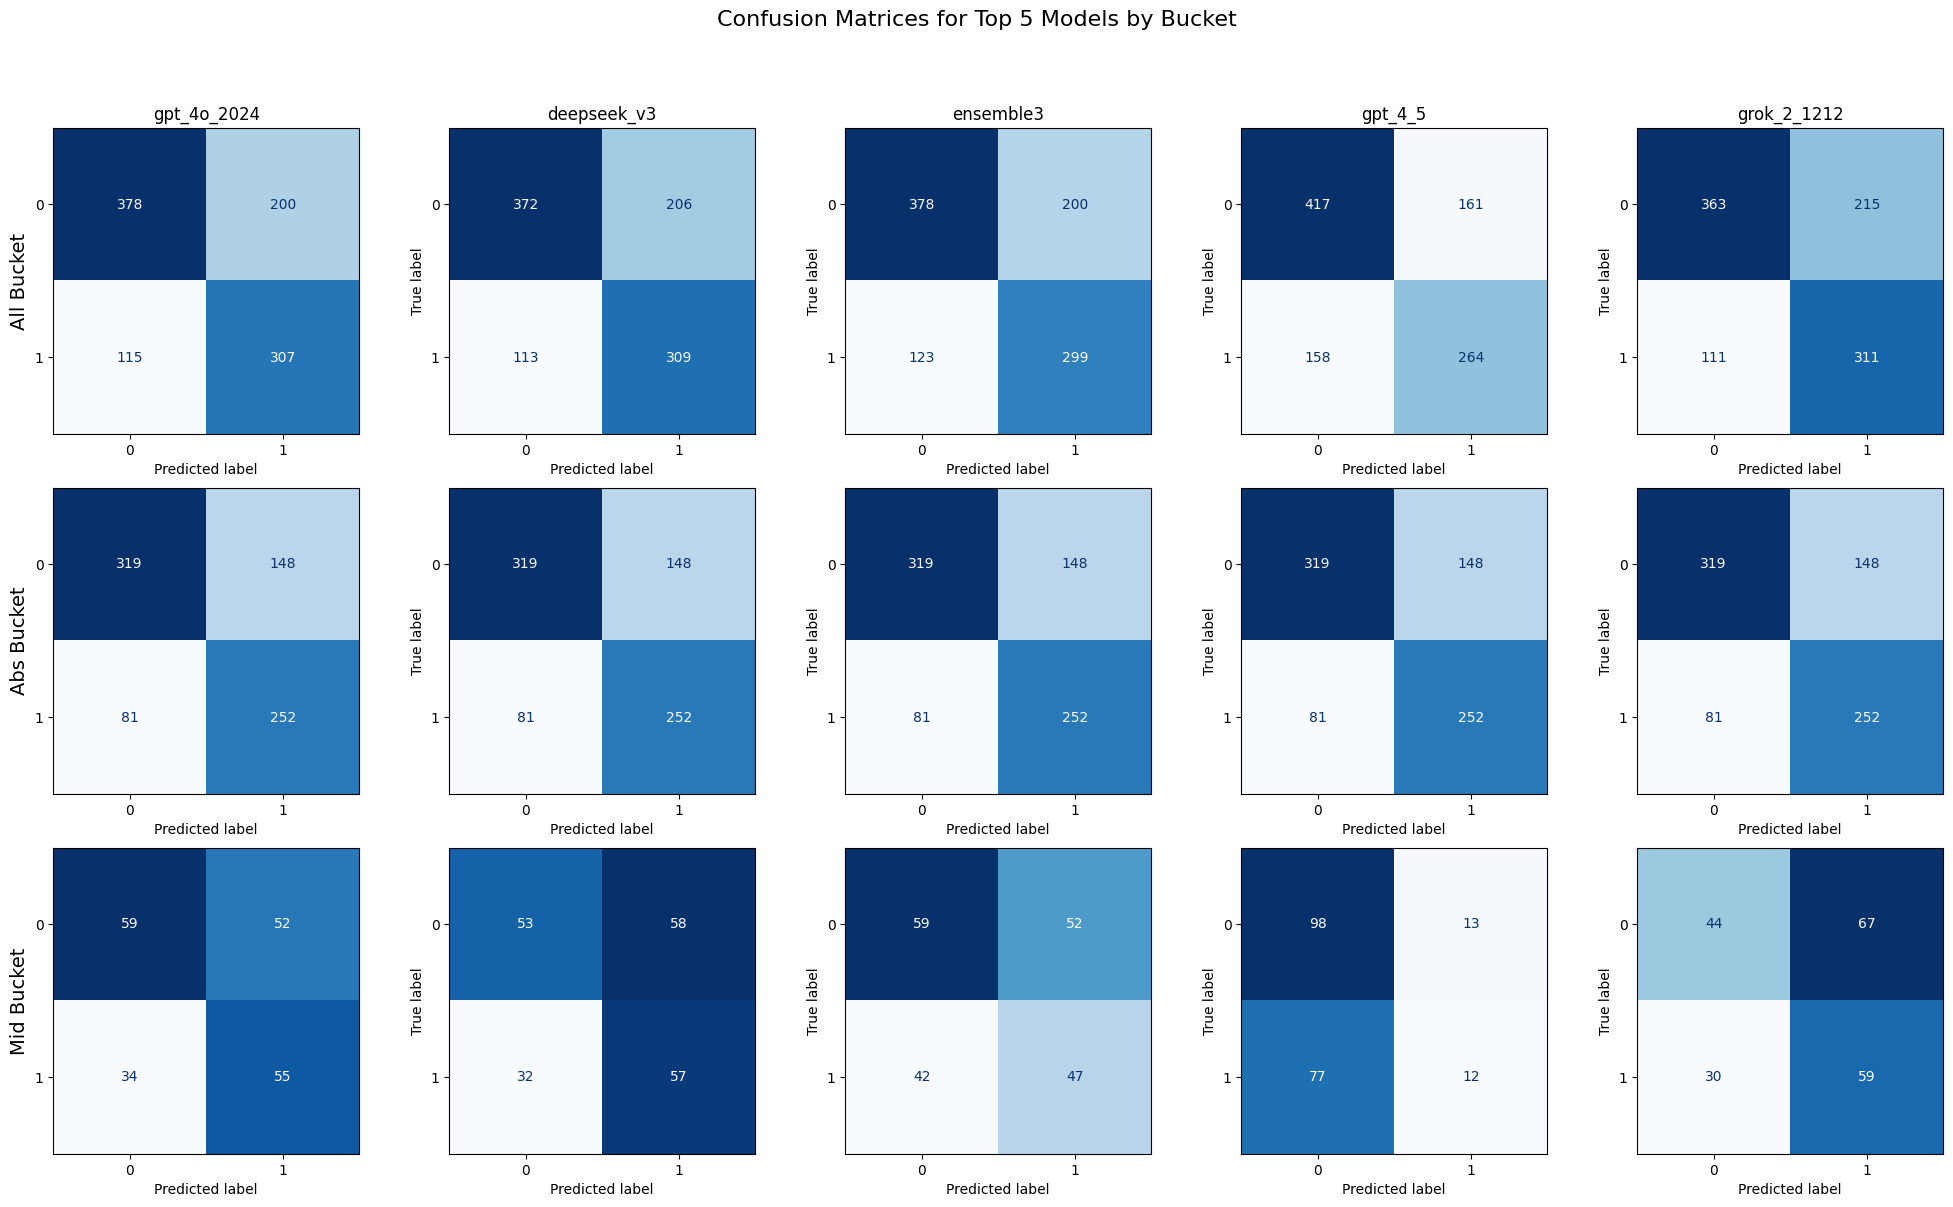

In [85]:
fig, axs = plt.subplots(3, 5, figsize=(20, 12))

for i, model in enumerate(top5):
    subdf_all = df_bool[df_bool.n_type.isin(buckets['all'])]
    cm_all = confusion_matrix(subdf_all['human'].tolist(), subdf_all[model].tolist())
    disp_all = ConfusionMatrixDisplay(confusion_matrix=cm_all, display_labels=[0, 1])
    disp_all.plot(cmap=plt.cm.Blues, ax=axs[0, i], colorbar=False)
    axs[0, i].set_title(f"{model}")

    subdf_abs = df_bool[df_bool.n_type.isin(buckets['abs'])]
    cm_abs = confusion_matrix(subdf_abs['human'].tolist(), subdf_abs[model].tolist())
    disp_abs = ConfusionMatrixDisplay(confusion_matrix=cm_abs, display_labels=[0, 1])
    disp_abs.plot(cmap=plt.cm.Blues, ax=axs[1, i], colorbar=False)

    subdf_mid = df_bool[df_bool.n_type.isin(buckets['mid'])]
    cm_mid = confusion_matrix(subdf_mid['human'].tolist(), subdf_mid[model].tolist())
    disp_mid = ConfusionMatrixDisplay(confusion_matrix=cm_mid, display_labels=[0, 1])
    disp_mid.plot(cmap=plt.cm.Blues, ax=axs[2, i], colorbar=False)

# Add row labels
axs[0, 0].set_ylabel("All Bucket", fontsize=14)
axs[1, 0].set_ylabel("Abs Bucket", fontsize=14)
axs[2, 0].set_ylabel("Mid Bucket", fontsize=14)

plt.suptitle("Confusion Matrices for Top 5 Models by Bucket", fontsize=16, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# POLPOS PAIRS

In [3]:
nodes = pd.read_csv('data/polpos_pairs_2210/sample_100_from_nan_2025-10-23.csv')
pairs = pd.read_csv('data/polpos_pairs_2210/pairs_934_2025-10-27b.csv')[['id1','id2']]

In [32]:
def process_results(results: str, nodes: str, pairs: str, demo: str) -> pd.DataFrame:
    nodes = pd.read_csv(nodes)
    pairs = pd.read_csv(pairs)[['id1','id2']]
    results = pd.read_csv(results)
    demo = pd.read_csv(demo)
    
    demo.rename(columns={c:c.lower().replace("(","").replace(")","").replace(" ","_") for c in demo.columns}, inplace=True)
    dfd = demo[['participant_id', 'age', 'political_affiliation_uk', 'sex']]
    
    results.rename(columns={c:c.lower().replace("(","").replace(")","").replace(" ","_") for c in results.columns}, inplace=True)
    results.rename(columns={c:c.replace("annotator","a") for c in results.columns if "annotator" in c}, inplace=True)
    results.meta_cat2 = results.meta_cat2.str.replace("_1","")

    results["a1_label"] = results.a1_response.map({"Statement 1": 1, "Statement 2": 2, "Equal": 0})
    results["a2_label"] = results.a2_response.map({"Statement 1": 1, "Statement 2": 2, "Equal": 0})
    results["a3_label"] = results.a3_response.map({"Statement 1": 1, "Statement 2": 2, "Equal": 0})

    dfr = results[['meta_id1','meta_id2', 'a1_id', 'a2_id', 'a3_id', 'a1_label', 'a2_label', 'a3_label']]
    
    dfl = pd.DataFrame([
        {
            'meta_id1': row['meta_id1'],
            'meta_id2': row['meta_id2'],
            'a_id': row[f'a{i}_id'],
            'label': row[f'a{i}_label'],
        }
        for _, row in dfr.iterrows()
        for i in [1,2,3]
    ])
    
    dfld = dfl.merge(dfd, left_on='a_id', right_on='participant_id', how='left').drop(columns=['a_id'])

    cols = ['meta_id'] + [c for c in nodes.columns if "political_position_array" in c or "political_position_mean" in c]
    dfo = nodes[cols]
    
    # dfldo = dfld.merge(dfo, on='meta_id', how='left')

    # dfro = dfr.merge(dfo, on='meta_id', how='left')
    
    return dfr, dfl, dfld, dfo, dfd


## LEFT

In [51]:
dfr, dfl, dfld, dfo, dfd = process_results(
    results='data/polpos_pairs_2210/prolific_results_left.csv',
    nodes='data/polpos_pairs_2210/sample_100_from_nan_2025-10-23.csv',
    pairs='data/polpos_pairs_2210/pairs_934_2025-10-27b.csv',
    demo='data/polpos_pairs_2210/prolific_demographic_left.csv',
)

dfld.to_csv('data/polpos_pairs_2210/prolific_results_left_merged.csv', index=False, encoding='utf-8')

dfld

,meta_id1,meta_id2,label,participant_id,age,political_affiliation_uk,sex
0,o5eCYPbhqyUday6mP655hs,GjT3ZtS2snTTrq6z9fGgkk,2,62a3b97d41ae082b602e815b,33,Left,Male
1,o5eCYPbhqyUday6mP655hs,GjT3ZtS2snTTrq6z9fGgkk,1,675cca3a27cd0a6fc7c16a9a,35,Right,Male
2,o5eCYPbhqyUday6mP655hs,GjT3ZtS2snTTrq6z9fGgkk,2,62aa591a476ebabe28612a92,35,Left,Male
3,hwFoAAfkMbRUkXsn4h2msF,oRr7T5vJAecAotQthqnghG,0,5e40458fee95202846ccf7f3,31,Left,Prefer not to say
4,hwFoAAfkMbRUkXsn4h2msF,oRr7T5vJAecAotQthqnghG,0,681b781064a5701a5ceee3bc,54,Left,Female
...,...,...,...,...,...,...,...
2797,TrbJZN9NaHS9fQFF8YhMWS,SRDbvkqjTnPe7fvECU4yrY,2,5df03fabc1ef790aa5595f8f,46,Centre,Female
2798,TrbJZN9NaHS9fQFF8YhMWS,SRDbvkqjTnPe7fvECU4yrY,2,60d3136e74b1871646e72544,47,Centre,Male
2799,jr8Xrm6bMdWLdJPYfthUa9,hd5SHwFgurzj8vm3U5uaKK,1,5e89ec793c01b3685a00bb12,46,Right,Male
2800,jr8Xrm6bMdWLdJPYfthUa9,hd5SHwFgurzj8vm3U5uaKK,0,63af557b3d4f219c3226b7d6,51,Left,Female


#### Check/approve

In [ ]:
# Investigate uniform labelling by annotators

pids = dfld['participant_id'].unique()

for pid in pids:
    subdf = dfld[dfld['participant_id'] == pid]
    if subdf['label'].nunique()==1:
        print(f"Participant {pid} uniform {sum(subdf['label'])/len(subdf)}")

        indiv_human_comparison = []
        for _, row in subdf.iterrows():
            otherpreds = dfld.loc[
                (dfld.meta_id1==row.meta_id1)&(dfld.meta_id2==row.meta_id2)&(dfld.participant_id!=pid), 
                'label'
            ].tolist()
            indiv_human_comparison.append(sum([1 for o in otherpreds if o==row['label']])/len(otherpreds))
            
        human_predicted = np.mean(indiv_human_comparison)
        print(f"Agreement with others: {human_predicted:.3f}")

    #     model_predicted = sum([1-v for v in subdf['ensemble3_political_position_probability_of_na']])
    #     model_diff = abs(model_predicted - sum(subdf['label']))/len(subdf)

    #     if model_diff > .2 and human_diff > .2:
    #         print(f"Participant {pid} uniform {sum(subdf['label'])/len(subdf)}")
    #         print(f"| Model predicted: {model_predicted/len(subdf):.3f}, diff: {model_diff:.0%}")
    #         print(f"| Other humans predicted: {human_predicted/len(subdf):.3f}, diff: {human_diff:.0%}")

Participant 67aa54c162dc637de018fe18 uniform 1.0
Agreement with others: 0.417
Participant 66598d6e838231ffe9e1613b uniform 1.0
Agreement with others: 0.833
Participant 5b01842bc573030001c345e0 uniform 1.0
Agreement with others: 0.500
Participant 5f5bb87a0093333445af65f2 uniform 1.0
Agreement with others: 0.333
Participant 586fabdf2bd3c900018599a9 uniform 1.0
Agreement with others: 0.333
Participant 5fff2877a99bcb65a14a223c uniform 2.0
Agreement with others: 0.083
Participant 65cbbbcc5c1ef8b850c91eb5 uniform 1.0
Agreement with others: 0.667
Participant 5f1be78aa15802413bb40998 uniform 1.0
Agreement with others: 0.583
Participant 5e89ec793c01b3685a00bb12 uniform 1.0
Agreement with others: 0.667
Participant 5e1aeccbd32f9332c931651e uniform 1.0
Agreement with others: 0.417
Participant 67cc5cbea659ba65853fab99 uniform 1.0
Agreement with others: 0.500
Participant 5e8efa2ce7ea51000c5ee81c uniform 1.0
Agreement with others: 0.417
Participant 676b89007874c8eace113276 uniform 1.0
Agreement with 

In [41]:
pids = list(dfld.participant_id.unique())

with open('approve_left.txt', 'w') as f:
    for pid in pids:
        f.write(f"{pid}\n")

## RIGHT

In [52]:
dfr, dfl, dfld, dfo, dfd = process_results(
    results='data/polpos_pairs_2210/prolific_results_right_clean.csv',
    nodes='data/polpos_pairs_2210/sample_100_from_nan_2025-10-23.csv',
    pairs='data/polpos_pairs_2210/pairs_934_2025-10-27b.csv',
    demo='data/polpos_pairs_2210/prolific_demographic_right.csv',
)

dfld.to_csv('data/polpos_pairs_2210/prolific_results_right_merged.csv', index=False, encoding='utf-8')


dfld

,meta_id1,meta_id2,label,participant_id,age,political_affiliation_uk,sex
0,HiK2tia5ncZ24wuWQmHkYo,Tkr23iAycEd2rQc7sX8jzk,1,5efa4bdaca4722143101c0bc,51,Left,Female
1,HiK2tia5ncZ24wuWQmHkYo,Tkr23iAycEd2rQc7sX8jzk,0,5e7dba4f1d6961436474c8f2,40,Centre,Female
2,HiK2tia5ncZ24wuWQmHkYo,Tkr23iAycEd2rQc7sX8jzk,2,5a5bd24be0cf3d000126849e,48,Centre,Female
3,hUbtCLxyLAgYznL3i7oiUt,VMajrkTgPVSu5GLfXWw7S3,0,66cb2e0bd2169db778550269,25,Centre,Male
4,hUbtCLxyLAgYznL3i7oiUt,VMajrkTgPVSu5GLfXWw7S3,1,5af573e7b4dfd600018fc0be,50,Left,Female
...,...,...,...,...,...,...,...
2797,AKiFCqePsjpBGGUN4kMXRP,o5eCYPbhqyUday6mP655hs,2,67c4cf035a34c6ef254906e2,28,Left,Male
2798,AKiFCqePsjpBGGUN4kMXRP,o5eCYPbhqyUday6mP655hs,1,60b8a2ea5eb4ad8ae98302f9,45,Centre,Female
2799,AKiFCqePsjpBGGUN4kMXRP,2sErDnSUMMDS5TZk9cza5X,1,677402fa760bab6fb5210f9a,44,Centre,Male
2800,AKiFCqePsjpBGGUN4kMXRP,2sErDnSUMMDS5TZk9cza5X,1,5d82b6d0ba839000153bc230,27,Left,Female


#### Check/approve

In [49]:
# Investigate uniform labelling by annotators

pids = dfld['participant_id'].unique()

for pid in pids:
    subdf = dfld[dfld['participant_id'] == pid]
    if subdf['label'].nunique()==1:
        print(f"Participant {pid} uniform {sum(subdf['label'])/len(subdf)}")

        indiv_human_comparison = []
        for _, row in subdf.iterrows():
            otherpreds = dfld.loc[
                (dfld.meta_id1==row.meta_id1)&(dfld.meta_id2==row.meta_id2)&(dfld.participant_id!=pid), 
                'label'
            ].tolist()
            indiv_human_comparison.append(sum([1 for o in otherpreds if o==row['label']])/len(otherpreds))
            
        human_predicted = np.mean(indiv_human_comparison)
        print(f"Agreement with others: {human_predicted:.3f}")

    #     model_predicted = sum([1-v for v in subdf['ensemble3_political_position_probability_of_na']])
    #     model_diff = abs(model_predicted - sum(subdf['label']))/len(subdf)

    #     if model_diff > .2 and human_diff > .2:
    #         print(f"Participant {pid} uniform {sum(subdf['label'])/len(subdf)}")
    #         print(f"| Model predicted: {model_predicted/len(subdf):.3f}, diff: {model_diff:.0%}")
    #         print(f"| Other humans predicted: {human_predicted/len(subdf):.3f}, diff: {human_diff:.0%}")

Participant 5d092c1f7dad2200193be669 uniform 2.0
Agreement with others: 0.750
Participant 5c3e80671580e9000122d168 uniform 2.0
Agreement with others: 0.417
Participant 5cb988a6b3e70d0001715d79 uniform 0.0
Agreement with others: 0.417
Participant 5e1bdbfd1795083ead4af5ee uniform 2.0
Agreement with others: 0.500
Participant 5a7f38f0eea3d300016e3767 uniform 2.0
Agreement with others: 0.417
Participant 67e95b4ce056cb97ac8a5c21 uniform 2.0
Agreement with others: 0.333
Participant 67403de187ba0c277a19a258 uniform 2.0
Agreement with others: 0.750


In [50]:
pids = list(dfld.participant_id.unique())

with open('approve_right.txt', 'w') as f:
    for pid in pids:
        f.write(f"{pid}\n")